# Project 2 — Visual Tracking Tutorial (Goalkeeper Assistant)

**Deliverables:** Jupyter Notebook (65%), short video presentation (35%).

This notebook provides a step-by-step implementation of a visual tracking pipeline in Python. The chosen real-world scenario is **penalty kick analysis**: tracking the ball and predicting its short-term trajectory to assist a goalkeeper.


In [14]:
# Notebook configuration
# FAST_MODE=True skips slow cells (video rendering / batch extraction).
FAST_MODE = True


## 1. Real-world problem and motivation

In penalty kicks, reaction time is limited and the ball can move fast enough that early trajectory cues are valuable. The goal of this project is to track the ball in a fixed-camera video and estimate its motion over time.

**Application examples:** sports analytics, goalkeeper training, and (more generally) motion tracking for surveillance/monitoring.


## 2. Choice of tracking algorithm

We combine two classic components:

1) **Background Subtraction (MOG2)** to obtain candidate moving regions (foreground mask).
2) **Kalman Filter** to smooth the noisy detections and provide predictions when detections are missing (e.g., occlusion).

This combination is well suited for fixed-camera scenes: MOG2 isolates motion while the Kalman filter provides a principled *predict-correct* framework for tracking.


## Video codec note (AV1 vs H.264)

The original YouTube download is encoded with **AV1**. While `ffmpeg` can decode AV1, `cv2.VideoCapture` may fail to read AV1 streams depending on the local FFmpeg/OpenCV build (e.g., missing AV1 decoder support).

To ensure reproducibility, we convert the input video to a widely supported codec (**H.264**) before processing:

```bash
ffmpeg -y -i input.mp4 -c:v libx264 -crf 20 -preset veryfast -pix_fmt yuv420p -c:a aac -b:a 128k input_h264.mp4
```

In the rest of this notebook we use `input_h264.mp4`.


## (Optional) Automatic penalty-kick clip extraction

If you already know the exact timestamp windows for each penalty kick, you can skip the automatic scan and directly use the pre-generated manual clips in `penalty_clips_manual/` (see `penalty_manual.csv`).

Alternatively, you can run the heuristic segmenter (`penalty_segmenter.py`) to propose candidate windows.


## Optional (slow) — Rendering videos / batch runs

The cells below can take longer and may generate video files.
They are **not required** to understand the method, but they are useful for producing the final demo outputs.

Tip: if you only want a quick run, execute the notebook up to this section.


In [15]:
if not FAST_MODE:
    # Run the penalty segmenter (creates penalty_candidates.csv + penalty_clips/)
    # Note: this may take ~1-2 minutes depending on your machine.
    !python penalty_segmenter.py --video input_h264.mp4 --out_csv penalty_candidates.csv --extract --clips_dir penalty_clips --sample_fps 2.0 --min_interval_s 4 --kick_pre_s 2 --kick_post_s 6
else:
    print('FAST_MODE=True: skipping this slow cell')


FAST_MODE=True: skipping this slow cell


In [16]:
import csv

with open("penalty_manual.csv", newline="", encoding="utf-8") as f:
    rows = list(csv.DictReader(f))

# Backward/forward compatible column handling.
# Old format: candidate, kick_est_s, clip_start_s, clip_end_s
# New format (edited): idx, start_s, end_s
if rows and "candidate" not in rows[0] and {"idx","start_s","end_s"}.issubset(rows[0].keys()):
    converted = []
    for r in rows:
        i = int(float(r["idx"]))
        start = float(r["start_s"]) 
        end = float(r["end_s"]) 
        converted.append({
            "candidate": f"penalty_{i:02d}",
            "kick_est_s": (start + end) / 2.0,
            "clip_start_s": start,
            "clip_end_s": end,
        })
    rows = converted

# Print a compact summary
for r in rows:
    print(r["candidate"], "kick_est_s=", r["kick_est_s"], "clip=", r["clip_start_s"], "-", r["clip_end_s"]) 

rows[:3]  # show first entries


penalty_01 kick_est_s= 2.5 clip= 0.0 - 5.0
penalty_02 kick_est_s= 16.0 clip= 14.0 - 18.0
penalty_03 kick_est_s= 26.5 clip= 24.0 - 29.0
penalty_04 kick_est_s= 39.5 clip= 37.0 - 42.0
penalty_05 kick_est_s= 49.5 clip= 46.0 - 53.0
penalty_06 kick_est_s= 66.0 clip= 62.0 - 70.0
penalty_07 kick_est_s= 85.0 clip= 83.0 - 87.0
penalty_08 kick_est_s= 92.0 clip= 97.0 - 87.0


[{'candidate': 'penalty_01',
  'kick_est_s': 2.5,
  'clip_start_s': 0.0,
  'clip_end_s': 5.0},
 {'candidate': 'penalty_02',
  'kick_est_s': 16.0,
  'clip_start_s': 14.0,
  'clip_end_s': 18.0},
 {'candidate': 'penalty_03',
  'kick_est_s': 26.5,
  'clip_start_s': 24.0,
  'clip_end_s': 29.0}]

In [17]:
# Choose which extracted clip to analyze (manual timestamps)
# Example: use penalty_05.mp4
from pathlib import Path
CHOSEN = Path('penalty_clips_manual') / 'penalty_05.mp4'
assert CHOSEN.exists(), CHOSEN
VIDEO_PATH = CHOSEN
print('Using VIDEO_PATH =', VIDEO_PATH)


Using VIDEO_PATH = penalty_clips_manual/penalty_05.mp4


In [18]:
# 3. Setup
import os
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

WORKDIR = Path('.').resolve()
FAST_MODE = True  # set False if you want to run the slow rendering cells
VIDEO_PATH = WORKDIR / ('clip.mp4' if (WORKDIR / 'clip.mp4').exists() else 'input_h264.mp4')
print('WORKDIR   =', WORKDIR)
print('VIDEO     =', VIDEO_PATH)
print('Exists    =', VIDEO_PATH.exists())


WORKDIR   = /home/tuti/Documentos/Master/practice2
VIDEO     = /home/tuti/Documentos/Master/practice2/input_h264.mp4
Exists    = True


In [19]:
# 4. Inspect video properties
cap = cv2.VideoCapture(str(VIDEO_PATH))
assert cap.isOpened(), f'Could not open video: {VIDEO_PATH}'
fps = cap.get(cv2.CAP_PROP_FPS)
w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
n   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
dur = n / fps if fps else None
print(f'FPS={fps:.3f}  size={w}x{h}  frames={n}  duration~{dur:.1f}s')
cap.release()


FPS=30.000  size=1920x1080  frames=3508  duration~116.9s


## 3. Step-by-step tutorial

### 3.1 (Optional but recommended) Choose a short, continuous segment

Broadcast videos may contain camera cuts or zooms. Since background subtraction assumes a mostly stationary camera, we will typically work on a short segment where the camera is stable and the penalty kick action is continuous.

In the next cell we provide helper code to extract a clip using `ffmpeg`.


In [20]:
if not FAST_MODE:
    # Helper command (run in a terminal) to extract a short clip
    # Example: extract from t_start=20s to t_end=30s
    # ffmpeg -y -ss 20 -to 30 -i input_h264.mp4 -c copy clip.mp4

    print('If needed, create a clip.mp4 (H.264) and set VIDEO_PATH accordingly.')
else:
    print('FAST_MODE=True: skipping this slow cell')


FAST_MODE=True: skipping this slow cell


**Chosen working clip:** For the remainder of this notebook we use a short continuous segment extracted from the full video to avoid camera cuts and reduce background-subtraction drift.

- Source: `input_h264.mp4`
- Clip: `clip.mp4` (selected around the penalty-kick wide shot)
- Extraction command used (example):

```bash
ffmpeg -y -ss 38 -to 50 -i input_h264.mp4 -c copy clip.mp4
```

(The exact time range may be adjusted after visual inspection.)


### 3.2 Define a Region of Interest (ROI)

To reduce false detections (player, crowd, etc.), we can restrict processing to an ROI around the goal area. This step is often critical when using motion-based detectors on broadcast footage.


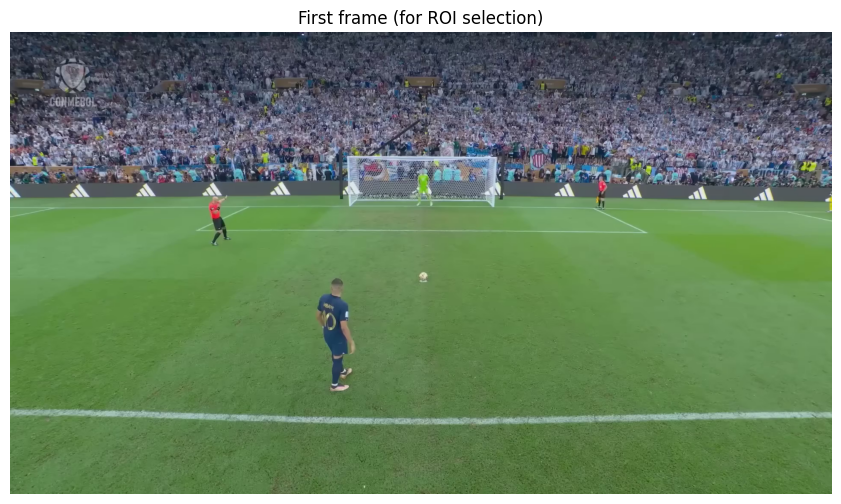

In [21]:
# Read the first frame and display it (for ROI selection)
cap = cv2.VideoCapture(str(VIDEO_PATH))
ret, frame_bgr = cap.read()
cap.release()
assert ret, 'Could not read first frame.'
frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12,6))
plt.imshow(frame_rgb)
plt.title('First frame (for ROI selection)')
plt.axis('off')
plt.show()


In [22]:
# Define ROI manually (x, y, w, h).
# TODO: update after inspecting the frame.
ROI = (600, 180, 750, 420)  # (x, y, w, h) around the goal
print('ROI =', ROI)


ROI = (600, 180, 750, 420)


### 3.3 Background subtraction (MOG2) + contour-based measurement

We create a foreground mask using MOG2, clean it with morphological operations, and then extract contours. The ball measurement $z_k$ is the detected centroid $(x, y)$.

Later we will add **gating**: only accept detections near the Kalman prediction to avoid confusing the ball with other moving objects.


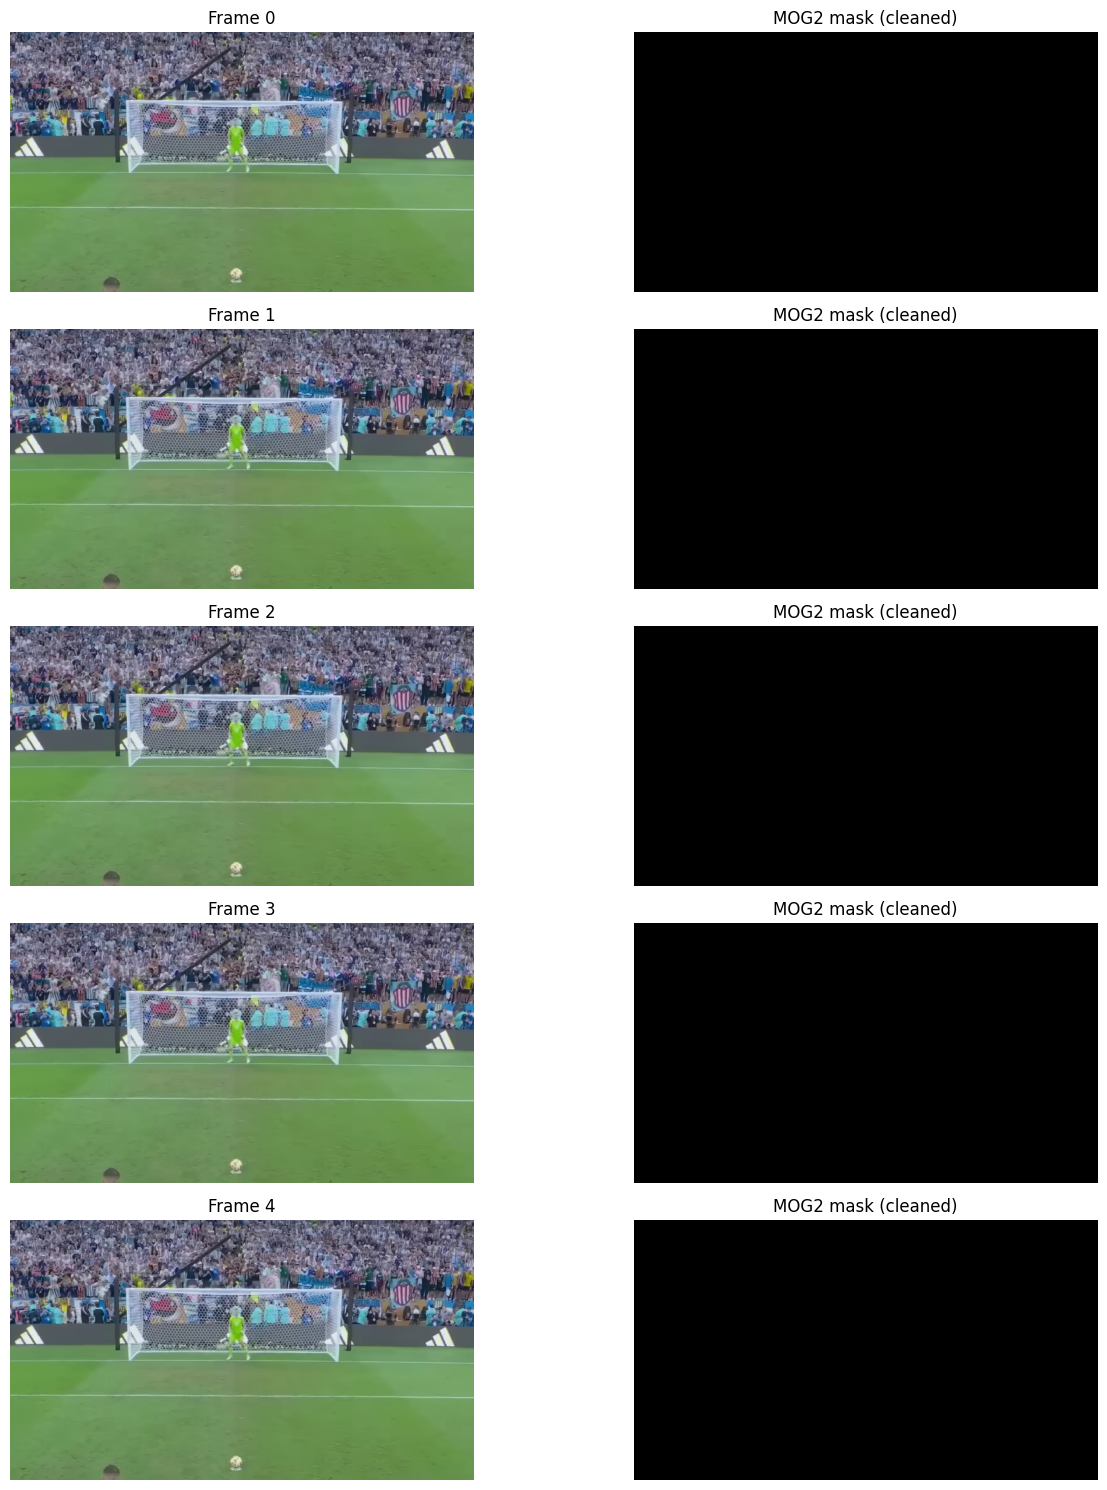

In [23]:
# MOG2 foreground mask demo on a few frames
cap = cv2.VideoCapture(str(VIDEO_PATH))
mog2 = cv2.createBackgroundSubtractorMOG2(history=200, varThreshold=16, detectShadows=True)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))

frames_to_show = 5
shown = 0
plt.figure(figsize=(14, 3*frames_to_show))
while shown < frames_to_show:
    ret, frame = cap.read()
    if not ret: break
    if ROI is not None:
        x,y,w,h = ROI
        frame = frame[y:y+h, x:x+w]
    fg = mog2.apply(frame)
    # remove shadows (shadows are 127 in OpenCV's MOG2 mask)
    fg[fg == 127] = 0
    fg = cv2.morphologyEx(fg, cv2.MORPH_OPEN, kernel, iterations=1)
    fg = cv2.morphologyEx(fg, cv2.MORPH_CLOSE, kernel, iterations=2)

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.subplot(frames_to_show, 2, 2*shown+1)
    plt.imshow(frame_rgb)
    plt.title(f'Frame {shown}')
    plt.axis('off')

    plt.subplot(frames_to_show, 2, 2*shown+2)
    plt.imshow(fg, cmap='gray')
    plt.title('MOG2 mask (cleaned)')
    plt.axis('off')
    shown += 1

cap.release()
plt.tight_layout()
plt.show()


### 3.4 Kalman filter (predict & correct)

We use a constant-velocity model with a 4D state: $x_k = [x, y, v_x, v_y]^T$.

- **Prediction:** estimates the next state from the motion model.
- **Correction (update):** if a measurement $z_k = [x, y]^T$ is available, we fuse it to reduce uncertainty.

If detection fails (occlusion/noise), we skip the correction step and rely on prediction.


In [24]:
# Kalman filter initialization (OpenCV implementation)
# State: [x, y, vx, vy]
kf = cv2.KalmanFilter(4, 2)
dt = 1.0 / max(1e-6, fps)
kf.transitionMatrix = np.array([[1, 0, dt, 0],
                                [0, 1, 0, dt],
                                [0, 0, 1, 0],
                                [0, 0, 0, 1]], dtype=np.float32)
kf.measurementMatrix = np.array([[1, 0, 0, 0],
                                 [0, 1, 0, 0]], dtype=np.float32)
# Tune these two matrices depending on noise levels
kf.processNoiseCov = np.eye(4, dtype=np.float32) * 1e-2
kf.measurementNoiseCov = np.eye(2, dtype=np.float32) * 1e0
kf.errorCovPost = np.eye(4, dtype=np.float32) * 1.0
print('Kalman initialized with dt=', dt)


Kalman initialized with dt= 0.03333333333333333


## 4. Challenges and possible improvements

Typical challenges in this scenario include:

- **Camera cuts / zoom**: break the stationary-background assumption of MOG2.
- **Shadows**: MOG2 may label shadows as foreground (handled by disabling 127 values or tuning `detectShadows`).
- **Small/fast ball**: motion blur reduces contour reliability.
- **Non-linear trajectories** (spin/Magnus effect): a linear constant-velocity Kalman model is a simplification; an EKF/UKF or particle filter could model curvature.

Improvements we can add if time permits:

- ROI selection + Kalman gating to reduce false positives.
- Better appearance model (color/HSV thresholding for the ball).
- Switch to **EKF** or include acceleration in the state.


## 5. Practical workflow used in this project

To make the notebook reproducible and robust on broadcast footage, we use the following workflow:

1) Convert AV1 → H.264 (if needed).
2) Extract a short continuous clip (`clip.mp4`).
3) Select an ROI around the goal to reduce false positives.
4) Run MOG2 to get candidate blobs, pick the best ball-like blob, and feed it into a Kalman filter.


### 5.1 ROI helper images

To select an ROI quickly, we export a reference frame and a grid-overlay frame. Use them to read approximate pixel coordinates.

Files created (in the project folder):

- `roi_helper/frame.jpg`
- `roi_helper/frame_grid.jpg`


In [25]:
# Generate ROI helper images (optional; already generated once in this workspace)
from pathlib import Path
import cv2

outdir = Path('roi_helper')
outdir.mkdir(exist_ok=True, parents=True)
cap = cv2.VideoCapture(str(VIDEO_PATH))
cap.set(cv2.CAP_PROP_POS_MSEC, 1000)
ret, frame = cap.read()
cap.release()
assert ret
cv2.imwrite(str(outdir/'frame.jpg'), frame)
# grid
img = frame.copy()
h,w = img.shape[:2]
step = 100
for x in range(0,w,step):
    cv2.line(img,(x,0),(x,h-1),(0,255,255),1)
    cv2.putText(img,str(x),(x+2,20),cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,255,255),1,cv2.LINE_AA)
for y in range(0,h,step):
    cv2.line(img,(0,y),(w-1,y),(0,255,255),1)
    cv2.putText(img,str(y),(2,y+18),cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,255,255),1,cv2.LINE_AA)
cv2.imwrite(str(outdir/'frame_grid.jpg'), img)
print('Wrote ROI helper frames to', outdir)


Wrote ROI helper frames to roi_helper


### 5.2 Full tracking loop (MOG2 measurement + Kalman predict/correct)

Below is a compact reference implementation. It is intentionally written as a tutorial: the detection produces a measurement $z_k=(x,y)$ when possible, and the Kalman filter provides a predicted state otherwise.

**Important:** The blob filtering thresholds (`min_area`, `max_area`, circularity, etc.) are video-dependent and should be tuned after setting the ROI.


In [26]:
def detect_ball_centroid(frame_bgr, fgmask, min_area=150, max_area=20000):
    """Return (x,y) centroid for the best ball-like contour, or None."""
    cnts, _ = cv2.findContours(fgmask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    best = None
    best_score = -1
    for c in cnts:
        area = cv2.contourArea(c)
        if area < min_area or area > max_area:
            continue
        x,y,wc,hc = cv2.boundingRect(c)
        if wc == 0 or hc == 0:
            continue
        ratio = wc / float(hc)
        if ratio < 0.5 or ratio > 2.0:
            continue
        per = cv2.arcLength(c, True)
        if per <= 0:
            continue
        circ = 4*np.pi*area/(per*per)
        # Higher circularity is more ball-like
        score = circ
        if score > best_score:
            M = cv2.moments(c)
            if M['m00'] == 0:
                continue
            cx = int(M['m10']/M['m00'])
            cy = int(M['m01']/M['m00'])
            best = (cx, cy)
            best_score = score
    return best


In [27]:
if not FAST_MODE:
    # Run tracking and render an output video (ROI + future projection)
    from pathlib import Path

    OUT_PATH = Path('processed_preview_roi.mp4')

    cap = cv2.VideoCapture(str(VIDEO_PATH))
    assert cap.isOpened()

    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(str(OUT_PATH), fourcc, fps, (W, H))

    # --- MOG2 (foreground mask) ---
    mog2 = cv2.createBackgroundSubtractorMOG2(history=120, varThreshold=20, detectShadows=True)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

    # --- Kalman filter (constant velocity) ---
    kf = cv2.KalmanFilter(4, 2)
    dt = 1.0 / fps
    kf.transitionMatrix = np.array([[1, 0, dt, 0],
                                    [0, 1, 0, dt],
                                    [0, 0, 1, 0],
                                    [0, 0, 0, 1]], np.float32)
    kf.measurementMatrix = np.array([[1, 0, 0, 0],
                                     [0, 1, 0, 0]], np.float32)

    # Tune these noise matrices if needed
    kf.processNoiseCov = np.eye(4, dtype=np.float32) * 1e-2
    kf.measurementNoiseCov = np.eye(2, dtype=np.float32) * 2e0
    kf.errorCovPost = np.eye(4, dtype=np.float32) * 10

    initialized = False
    track = []

    # Detection thresholds (ROI-dependent)
    min_area = 30
    max_area = 800
    min_circularity = 0.40

    # Warm up the background model on a few ROI frames
    if ROI is not None:
        x0, y0, w_roi, h_roi = ROI
    for _ in range(10):
        ret, frame = cap.read()
        if not ret: break
        if ROI is None:
            mog2.apply(frame)
        else:
            mog2.apply(frame[y0:y0+h_roi, x0:x0+w_roi])

    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

    frame_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Crop ROI for detection
        if ROI is None:
            x0, y0 = 0, 0
            roi_frame = frame
        else:
            x0, y0, w_roi, h_roi = ROI
            roi_frame = frame[y0:y0+h_roi, x0:x0+w_roi]

        # Foreground mask
        fg = mog2.apply(roi_frame)
        fg[fg == 127] = 0  # remove shadow label
        fg = cv2.morphologyEx(fg, cv2.MORPH_OPEN, kernel, iterations=1)
        fg = cv2.morphologyEx(fg, cv2.MORPH_CLOSE, kernel, iterations=2)

        # Find best ball-like contour
        cnts, _ = cv2.findContours(fg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        meas = None
        best = -1
        for c in cnts:
            area = cv2.contourArea(c)
            if area < min_area or area > max_area:
                continue
            per = cv2.arcLength(c, True)
            if per <= 0:
                continue
            circ = 4*np.pi*area/(per*per)
            if circ < min_circularity:
                continue
            M = cv2.moments(c)
            if M['m00'] == 0:
                continue
            cx = int(M['m10']/M['m00'])
            cy = int(M['m01']/M['m00'])
            if circ > best:
                best = circ
                meas = (cx, cy)

        # Kalman prediction
        pred = kf.predict()
        px, py = float(pred[0]), float(pred[1])

        # --- Kalman gating (reject far-away measurements) ---
        # This helps avoid confusing the ball with other moving blobs (players/crowd).
        gate_radius = 60  # pixels; tune for your video/ROI
        if initialized and meas is not None:
            mx, my = meas
            mxg, myg = mx + x0, my + y0
            if (mxg - px)**2 + (myg - py)**2 > gate_radius**2:
                meas = None

        # Kalman correction (if measurement exists)
        if meas is not None:
            mx, my = meas
            mxg, myg = mx + x0, my + y0
            if not initialized:
                kf.statePost = np.array([[mxg], [myg], [0], [0]], np.float32)
                initialized = True
            z = np.array([[np.float32(mxg)], [np.float32(myg)]])
            kf.correct(z)
            track.append((mxg, myg))
            cv2.circle(frame, (mxg, myg), 6, (0, 255, 0), 2)  # measurement

        # Draw prediction + future projection
        if initialized:
            cv2.circle(frame, (int(px), int(py)), 6, (0, 0, 255), 2)  # prediction
            # project 15 steps into the future
            s = kf.statePost.copy()
            fut = []
            for _ in range(15):
                s = kf.transitionMatrix @ s
                fut.append((int(s[0]), int(s[1])))
            for i in range(1, len(fut)):
                cv2.line(frame, fut[i-1], fut[i], (0, 0, 255), 2)

        # Draw ROI rectangle
        if ROI is not None:
            cv2.rectangle(frame, (x0, y0), (x0+w_roi, y0+h_roi), (255, 255, 0), 2)

        # Draw past trajectory
        for i in range(1, len(track)):
            cv2.line(frame, track[i-1], track[i], (255, 0, 0), 2)

        cv2.putText(frame, f'frame {frame_idx}', (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255,255,255), 2)
        writer.write(frame)
        frame_idx += 1

    cap.release()
    writer.release()
    print('Wrote', OUT_PATH.resolve())
    print('Track points:', len(track))
else:
    print('FAST_MODE=True: skipping this slow cell')


FAST_MODE=True: skipping this slow cell


## 6. Discussion (Phase 2 & 3 of the project plan)

### Phase 2 — Notebook as a step-by-step tutorial
In this notebook we deliberately structure the implementation into logical blocks: video preparation, ROI selection, motion-based measurements (MOG2), and state estimation (Kalman filter).

### Phase 3 — Challenges and improvements
**Main challenges observed:**

- Broadcast footage includes crowd motion and sometimes camera cuts. Using a short clip plus an ROI makes MOG2 usable.
- Shadows can be included in the foreground mask. We remove the shadow label (value 127) and apply morphological filtering.
- The ball may be very small/blurred; measurements become noisy. The Kalman filter smooths detections and provides predictions during short detection dropouts.

**Possible improvements:**

- Add Kalman gating (accept detections only near the predicted position).
- Use an appearance model (HSV color threshold, template matching) to reduce false positives.
- Extend the state to include acceleration or use an EKF/UKF for curved trajectories.


### Kalman gating (measurement validation)

A practical improvement is to **validate** the motion-based measurement before correcting the Kalman filter.

We accept a detection only if it is within a radius around the predicted position. This reduces false positives when multiple moving objects are present.


## Output video codec note (VLC compatibility)

The preview videos generated via OpenCV's `VideoWriter` may use the `mp4v` codec (MPEG-4 Part 2).
On some systems, VLC might not have the decoder enabled for `mp4v`.

If VLC cannot open the preview, convert it to H.264 (AVC) using `ffmpeg`:

```bash
ffmpeg -y -i processed_preview_roi.mp4 -c:v libx264 -crf 20 -preset veryfast -pix_fmt yuv420p -movflags +faststart processed_preview_roi_h264.mp4
```

The resulting file uses the widely supported `avc1` (H.264) codec.
